# Exploration of CLIP flaws

Multimodal model can have unexpected biases. CLIP, for example, is strongly biased toward text in the text. A great example can be found [here](https://arxiv.org/pdf/2508.05430#page=8.94), Figure 6, where CLIP "sees" a doll, but is actually focused on "dollar" text, not an actual doll. Is thid a **real** problem? Considering that most of the content on web is watermarked in some way, this might be an issue. During today's lab, we will try to reproduce this phenomena on ImageNet creating artifically injected watermarks.

The coding agenda is as follow:

1. load a CLIP and stream ImageNet dataset
2. create a custom version of dataset with injected watermarks
3. iterate over dataset, compute metrics on original and injected data
4. compute simple CAV (diff means)
5. debias representation of injected data and compare metric to the original data

In [1]:
import os
import numpy as np
from PIL import ImageFont, ImageDraw, Image as PILImage

### 00 Prelimaries

code below serves as utilty to inject watermarks. You need to pass `image` and `text` to be injected, the rest of parameters can be left as default. The watermark transformation can be used via 

```python
torchvision.transforms.Compose([partial(add_watermark, ...), clip_text_preprocessor])
```

In [2]:
_IMAGE_SIZE_TO_FONT_SIZE = {
    224: 36,
    384: 62,
    512: 82,
    518: 84,
}
_FONT_SIZE_RATIO = 6.22 


def add_watermark(
    image: np.ndarray | PILImage.Image,
    image_size: int = 224,
    text: str = "TEXT",
    font_path: str = "./assets/fonts/SourceHanSerifSC-ExtraLight.otf",
    opacity: float = 0.5,
    color: tuple[int, int, int] = (255, 255, 255),
    x_pos: float = 0.01,
    y_pos: float = 0.4,
) -> PILImage.Image:
    """
    Add semi-transparent text watermark overlay to an image.

    The watermark is composited using alpha blending, preserving the original
    image with the text rendered on top at the specified opacity.

    Args:
        image: Input PIL Image or numpy array to add watermark to
        image_size: Size of input image in pixels, used for font size calculation (default: 224)
        text: Watermark text to overlay (default: WATERMARK_TEXT)
        font_path: Path to TrueType/OpenType font file (default: SourceHanSerifSC-ExtraLight.otf)
        opacity: Watermark opacity in range [0.0, 1.0] where 0.0 is fully transparent 
            and 1.0 is fully opaque (default: 0.5)
        color: RGB color tuple for watermark text (default: (255, 255, 255) white)
        x_pos: Horizontal position as fraction of image width in range [0.0, 1.0] (default: 0.01)
        y_pos: Vertical position as fraction of image height in range [0.0, 1.0] (default: 0.4)

    Returns:
        PIL Image with watermark overlay applied, converted to RGB mode

    Raises:
        FileNotFoundError: If font_path doesn't exist
        ValueError: If opacity, x_pos, or y_pos are outside the valid range [0.0, 1.0]
    """
    # Validate font path
    if not os.path.exists(font_path):
        raise FileNotFoundError(f"Font file not found: {font_path}")

    # Validate range parameters
    if not 0.0 <= opacity <= 1.0:
        raise ValueError(f"Opacity must be in range [0.0, 1.0], got {opacity}")
    if not 0.0 <= x_pos <= 1.0:
        raise ValueError(f"x_pos must be in range [0.0, 1.0], got {x_pos}")
    if not 0.0 <= y_pos <= 1.0:
        raise ValueError(f"y_pos must be in range [0.0, 1.0], got {y_pos}")

    # Calculate appropriate font size
    if image_size in _IMAGE_SIZE_TO_FONT_SIZE:
        font_size = _IMAGE_SIZE_TO_FONT_SIZE[image_size]
    else:
        font_size = int(image_size / _FONT_SIZE_RATIO)

    font = ImageFont.truetype(font_path, font_size)

    # If np.array convert to PIL
    if isinstance(image, np.ndarray):
        image = PILImage.fromarray(image.astype(np.uint8), 'RGB')

    # Convert to RGBA for alpha compositing
    image_rgba = image.convert("RGBA")
    width, height = image_rgba.size

    # Create transparent overlay for watermark text
    watermark_layer = PILImage.new("RGBA", image_rgba.size, (255, 255, 255, 0))
    draw = ImageDraw.Draw(watermark_layer)

    # Draw text with specified opacity
    draw.text(
        xy=(x_pos * width, y_pos * height),
        text=text,
        fill=(*color, round(opacity * 255)),  # Cleaner tuple unpacking
        font=font,
    )

    # Composite watermark onto image and convert back to RGB
    output_img = PILImage.alpha_composite(image_rgba, watermark_layer).convert("RGB")
    return output_img

### 01 CLIP and Imagenet loading

You should already know how to load CLIP from previous labs. For ImageNet, you need to find it on HuggingFace. You can check for `imagenet-1k` for smaller volume. Note that "mini" version is still too bug to make the full experiment, so feel free to constraint experiments to 100-200 images. Use `streaming=True`, so the datasrt is not donwloaded on your PC/notebook, but is streamed from web. It is much slower, but fits our needs best.

Side note: `test` split of ImageNet does not have labels.

In [3]:
import torch
from transformers import CLIPProcessor, CLIPModel
from datasets import load_dataset

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
model_id = "openai/clip-vit-base-patch32"

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 30626.03it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
print("Loading ImageNet-1k validation split (streaming mode)...")
dataset = load_dataset(
    "imagenet-1k", 
    split="validation", 
    streaming=True, 
    trust_remote_code=True,
    token="token was here"
)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imagenet-1k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading ImageNet-1k validation split (streaming mode)...


In [16]:
num_images = 150
small_dataset = dataset.take(num_images)

### 02 Custom dataset

Because of `streaming=True`, you already have `IterableDatset` object. It already has `__getitem__` implemented, so we need to add our custom logic in `__iter__`. The logic should be as follows:

```python
    def __iter__(self):
        for example in self.dataset:
            <your code here>
            yield img, img_corrupted, label
```

Remember that `yield` should return `Tensor`, `dict[str, Tensor]`, or so. Ensure that your custom dataset returns (original image after CLIP processing, image after watermark injection and CLIP processing, original label).

Tip: datasets typically returns index of a class, not its label (e.g., `1`, not `goldfish`). You can still find label using `dataset.features["label"].int2str(IDX)`.

Tip 2: because of streaming, the biggest bottleneck is HuggingFace API, consider setting `batch_size` on `64` or more.

In [17]:
from torch.utils.data import IterableDataset
from torch.utils.data import DataLoader

class WatermarkedDataset(IterableDataset):
    def __init__(self, hf_dataset, processor, watermark_text="BLUEBERRY"):
        self.dataset = hf_dataset
        self.processor = processor
        self.watermark_text = watermark_text

    def __iter__(self):
        for example in self.dataset:
            img = example["image"]
            if img.mode != "RGB":
                img = img.convert("RGB")
            img_corrupted = add_watermark(img, text=self.watermark_text)

            processed_img = self.processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
            processed_corrupted = self.processor(images=img_corrupted, return_tensors="pt")["pixel_values"].squeeze(0)

            label_idx = example["label"]
            label_str = self.dataset.features["label"].int2str(label_idx)

            yield processed_img, processed_corrupted, label_str

custom_dataset = WatermarkedDataset(
    hf_dataset=small_dataset, 
    processor=processor, 
    watermark_text="BLOCKCHAIN"
)
dataloader = DataLoader(custom_dataset, batch_size=64)
iterator = iter(dataloader)

img_orig, img_corr, batch_label = next(iterator)

print(f"Oryginalny tensor shape: {img_orig.shape}")
print(f"Zakłócony tensor shape: {img_corr.shape}")
print(f"Etykieta: {len(batch_label)}")

Oryginalny tensor shape: torch.Size([64, 3, 224, 224])
Zakłócony tensor shape: torch.Size([64, 3, 224, 224])
Etykieta: 64


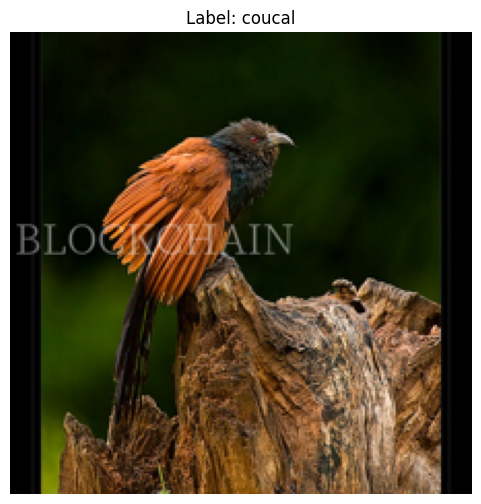

In [18]:
import matplotlib.pyplot as plt
first_img_tensor = img_corr[0]  
first_label = batch_label[0]  

img_np = first_img_tensor.cpu().numpy().transpose(1, 2, 0)

clip_mean = np.array([0.48145466, 0.4578275, 0.40821073])
clip_std = np.array([0.26862954, 0.26130258, 0.27577711])
img_np = (img_np * clip_std) + clip_mean

img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title(f"Label: {first_label}")
plt.axis("off")
plt.show()

### 03 Metrics computation

So far, you should have loaded CLIP and iterable dataset. Now it's time to creating **interesting** experiment. The design is up to you, but let's check my proposal below:

> - set watermark text to something like "BLUEBERRY"
> - use CLIP in zero-shot mode (comparing embedding of text and image)
> - check how many images will be predicted as "BLUEBERRY" rather than the original class
>   - e.g., compare cossim(image_watermark, "a photo of a BLUEBERRY") and cossim(image_watermark, "a photo of [ORIGINAL CLASS]")

After this step, you should tell the accuracy of the CLIP in distinguishing between BLUEBERRY and [ORIGINAL CLASS] on original data and data with watermarks (or analogous metrics in our own experiment design).

Tip: use `padding=True` when processing text in batches.

Note: I proposed BLUEBERRY for no particural reason, but keep in mind tht ImageNet contains ~all types of images so to be completly fair in this experiment we should choose something that does not occur in this dataset probably.

In [19]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

In [ ]:
correct_original = 0
correct_watermarked = 0
total_images = 0

watermark_text = "BLOCKCHAIN"

print("Rozpoczynam obliczanie metryk...")
for img_orig, img_corr, batch_labels in tqdm(dataloader):
    
    batch_size = img_orig.shape[0]
    prompts_original = [f"a photo of a {label}" for label in batch_labels]
    prompts_watermark = [f"a photo of a {watermark_text}"] * batch_size

    text_inputs_orig = processor(text=prompts_original, return_tensors="pt", padding=True).to(device)
    text_inputs_wm = processor(text=prompts_watermark, return_tensors="pt", padding=True).to(device)
    img_orig = img_orig.to(device)
    img_corr = img_corr.to(device)
    
    with torch.no_grad(): 
        outputs_orig = model(pixel_values=img_orig, **text_inputs_orig)
        outputs_corr = model(pixel_values=img_corr, **text_inputs_wm)
        img_features_orig = outputs_orig.image_embeds
        img_features_corr = outputs_corr.image_embeds
        text_features_orig = outputs_orig.text_embeds
        text_features_wm = outputs_corr.text_embeds

    img_features_orig = F.normalize(img_features_orig, p=2, dim=-1)
    img_features_corr = F.normalize(img_features_corr, p=2, dim=-1)
    text_features_orig = F.normalize(text_features_orig, p=2, dim=-1)
    text_features_wm = F.normalize(text_features_wm, p=2, dim=-1)

    sim_orig_to_orig_text = (img_features_orig * text_features_orig).sum(dim=-1)
    sim_orig_to_wm_text = (img_features_orig * text_features_wm).sum(dim=-1)

    sim_corr_to_orig_text = (img_features_corr * text_features_orig).sum(dim=-1)
    sim_corr_to_wm_text = (img_features_corr * text_features_wm).sum(dim=-1)

    correct_original += (sim_orig_to_orig_text > sim_orig_to_wm_text).sum().item()
    correct_watermarked += (sim_corr_to_orig_text > sim_corr_to_wm_text).sum().item()
    total_images += batch_size

acc_orig = (correct_original / total_images) * 100
acc_corr = (correct_watermarked / total_images) * 100

print("-" * 50)
print(f"Zero-shot Accuracy (Oryginalna Klasa vs '{watermark_text}'):")
print(f"-> Na czystych obrazach:           {acc_orig:.2f}%")
print(f"-> Na obrazach ze znakiem wodnym:  {acc_corr:.2f}%")
print("-" * 50)

Rozpoczynam obliczanie metryk...


3it [02:22, 47.45s/it] 

--------------------------------------------------
Zero-shot Accuracy (Oryginalna Klasa vs 'BLOCKCHAIN'):
-> Na czystych obrazach:           99.33%
-> Na obrazach ze znakiem wodnym:  91.33%
--------------------------------------------------


### 04 CAV computation

In this step, you should create a CAV (e.g., DiffMeans we used in previous work) and check its detection power - i.e., `rocauc(cossim(CAV, data))`. This should be really easy!

In [21]:
from sklearn.metrics import roc_auc_score

In [23]:
all_orig_features = []
all_corr_features = []

print("Ekstrakcja cech obrazów do CAV...")
with torch.no_grad():
    for img_orig, img_corr, _ in dataloader:
        img_orig = img_orig.to(device)
        img_corr = img_corr.to(device)

        outputs_orig = model(pixel_values=img_orig, **text_inputs_orig).image_embeds
        outputs_corr = model(pixel_values=img_corr, **text_inputs_wm).image_embeds
        feat_orig = F.normalize(outputs_orig, p=2, dim=-1)
        feat_corr = F.normalize(outputs_corr, p=2, dim=-1)
        all_orig_features.append(feat_orig.cpu())
        all_corr_features.append(feat_corr.cpu())

tensor_orig = torch.cat(all_orig_features, dim=0)
tensor_corr = torch.cat(all_corr_features, dim=0)

mean_orig = tensor_orig.mean(dim=0)
mean_corr = tensor_corr.mean(dim=0)

cav = mean_corr - mean_orig
cav = F.normalize(cav, p=2, dim=-1) 
sim_orig = (tensor_orig * cav).sum(dim=-1).numpy()
sim_corr = (tensor_corr * cav).sum(dim=-1).numpy()
y_true = np.concatenate([np.zeros(len(sim_orig)), np.ones(len(sim_corr))])
y_scores = np.concatenate([sim_orig, sim_corr])
roc_auc = roc_auc_score(y_true, y_scores)

print(f"ROC AUC dla CAV (DiffMeans): {roc_auc:.4f}")

Ekstrakcja cech obrazów do CAV...
ROC AUC dla CAV (DiffMeans): 0.9459


### 05 Debiasing

Now we have everything we need to make CLIP robust to watermarks. In this step, repeat the logic from **03**, but make an ortogonalisation of data with injected watermark. Ideally, its CLIP's embedding should be similar to the original data (you can check!); however, our main goal is to just improve the accuracy of zero-shot classification.

In [24]:
correct_debiased = 0
total_images = 0

watermark_text = "BLOCKCHAIN"

cav_tensor = cav.to(device)

print("Rozpoczynam ewaluację z debiasingiem...")
for img_orig, img_corr, batch_labels in tqdm(dataloader):
    
    batch_size = img_corr.shape[0]
    prompts_original = [f"a photo of a {label}" for label in batch_labels]
    prompts_watermark = [f"a photo of a {watermark_text}"] * batch_size

    text_inputs_orig = processor(text=prompts_original, return_tensors="pt", padding=True).to(device)
    text_inputs_wm = processor(text=prompts_watermark, return_tensors="pt", padding=True).to(device)
    
    img_corr = img_corr.to(device)
    
    with torch.no_grad():
        outputs_corr = model(pixel_values=img_corr, **text_inputs_wm)
        outputs_for_orig_text = model(pixel_values=img_corr, **text_inputs_orig)
        
        img_features_corr = outputs_corr.image_embeds
        text_features_wm = outputs_corr.text_embeds
        text_features_orig = outputs_for_orig_text.text_embeds

    img_features_corr = F.normalize(img_features_corr, p=2, dim=-1)
    text_features_orig = F.normalize(text_features_orig, p=2, dim=-1)
    text_features_wm = F.normalize(text_features_wm, p=2, dim=-1)

    dot_products = (img_features_corr * cav_tensor).sum(dim=-1, keepdim=True)

    projections = dot_products * cav_tensor
 
    img_features_debiased = img_features_corr - projections

    img_features_debiased = F.normalize(img_features_debiased, p=2, dim=-1)

    sim_debiased_to_orig_text = (img_features_debiased * text_features_orig).sum(dim=-1)
    sim_debiased_to_wm_text = (img_features_debiased * text_features_wm).sum(dim=-1)

    correct_debiased += (sim_debiased_to_orig_text > sim_debiased_to_wm_text).sum().item()
    total_images += batch_size

acc_debiased = (correct_debiased / total_images) * 100

print("-" * 50)
print(f"Zero-shot Accuracy (Oryginalna Klasa vs '{watermark_text}'):")
print(f"-> Skuteczność PO DEBIASINGU:  {acc_debiased:.2f}%")
print("-" * 50)

Rozpoczynam ewaluację z debiasingiem...


3it [01:09, 23.31s/it]

--------------------------------------------------
Zero-shot Accuracy (Oryginalna Klasa vs 'BLOCKCHAIN'):
-> Skuteczność PO DEBIASINGU:  96.00%
--------------------------------------------------
